# Week 2 Prep - Grouping with `groupby()`

## Grouping

Let’s start by loading the data:

In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


The general syntax for `groupby()` is:

`df.groupby(columns_to_group_by).summary_method()`

Most often, columns_to_group_by is a single column name (a string) or a list of column names. The unique values of the column (or columns) will be used as the groups of the data frame.

#### Example:
If we don’t use groupby() and directly apply the mean() method to our flipper length column, we obtain the average of all the values in the column:

In [2]:
penguins['flipper_length_mm'].mean()

200.91520467836258

To get the mean flipper length by species we first group our dataset by the species column’s values and specifying the operation:

In [3]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

Notice that the name of the series is the same as the column on which we calculated the summary statistic. We can easily update this using the `rename()` method:

In [4]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

We can also group by combinations of columns.

#### Example
Suppose we want to know the mean flipper length, this time by examining separately penguin species surveyed on each island.

In [5]:
# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values
Notice first that 11 penguins have no recorded sex. We can check this using:

* `size`: returns the number of observations in a `pandas.Series`
* `count()`: returns the number of non-NA observations in the series

In [6]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

By default, `groupby()` leaves out the rows where the grouping column has NA values. When we group by sex and count the number of observations (rows) we are left with, the 11 NA values are not included:

In [7]:
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

To keep the NA values as their own group, we use the `dropna=False` parameter:

In [8]:
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check-ins

We are interested in knowing the number of penguins surveyed on each island in different years.

1. Run `penguins.groupby(['island','year']).count()` and `penguins.groupby(['island','year']).size()`

In [14]:
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [12]:
penguins.groupby(['island','year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

2. Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

> The first one with .count() returns a data frame of all columns with a repeated number of penguins in each one, and the second one with .size() returns a series of the total number of penguins per group.

Let’s say we want to plot the surveyed population per year and island. We could then use method chaining to do this:

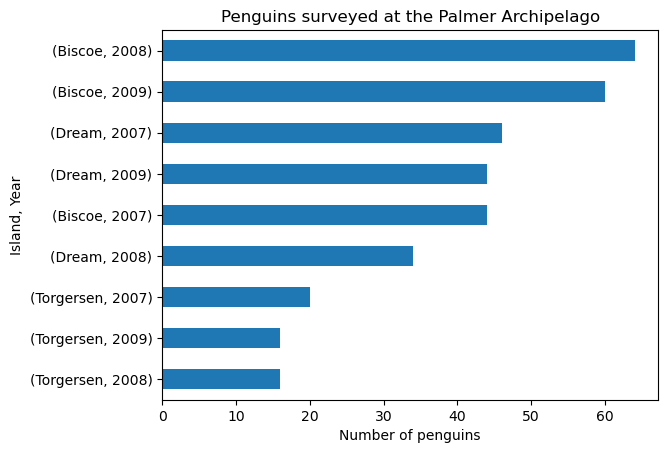

In [16]:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         );

1. Use the `max()` method to calculate the maximum value of a penguin’s body mass by year and species.

In [18]:
penguins.groupby(['year', 'species']).max('body_mass_g')

bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
year species                                                                 
2007 Adelie               46.0           21.5              198.0       4675.0
     Chinstrap            58.0           20.3              201.0       4400.0
     Gentoo               59.6           17.0              230.0       6300.0
2008 Adelie               45.8           21.1              208.0       4700.0
     Chinstrap            54.2           20.8              210.0       4800.0
     Gentoo               54.3           17.3              231.0       6000.0
2009 Adelie               45.6           20.7              210.0       4775.0
     Chinstrap            55.8           19.9              212.0       4450.0
     Gentoo               55.9           17.3              230.0       6000.0

2. Use (1) to display the highest body masses per year and species as a bar plot in descending order.

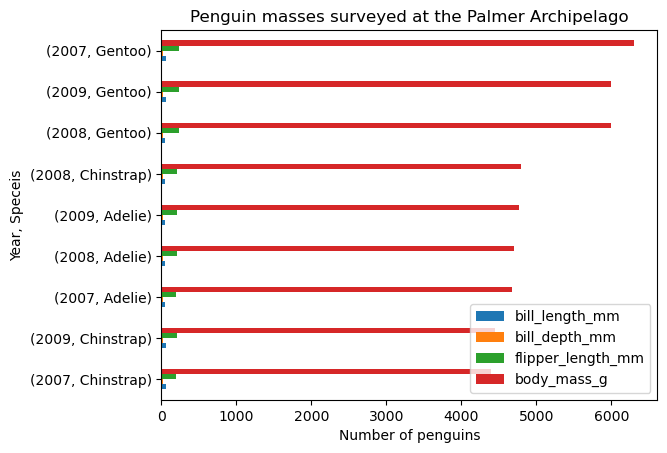

In [22]:
(penguins.groupby(['year', 'species']).max('body_mass_g')
         .sort_values(by='body_mass_g', ascending=True)
         .plot(kind='barh',
                title='Penguin masses surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Year, Speceis')
         );